## Word2Vec implemented in numpy DEMO

## Environment Setup

In [1]:
from types import SimpleNamespace
from word2vec import Vocab, Word2VecDataset, SGNSModel, SGD, Trainer, Word2VecPipeline
from word2vec.config import MODELS_DIR, DATASET_SIZES
from word2vec.utils import download_text8, plot_word_embeddings_3d

## Experiment Configuration

In [2]:
args = SimpleNamespace(
    size="medium",      # Dataset size preset (e.g., small, medium, big)
    epochs=3,           # Number of training epochs
    window=2,           # Context window size
    negatives=5,        # Number of negative samples per positive sample
    batch_size=128,     # Training batch size
    vocab_size=50000,   # Maximum vocabulary size
    embed_dim=100,      # Dimensionality of word embeddings
    lr=0.05             # Learning rate for SGD
)

print(f"\n{'='*50}")
print(f"🚀 Starting Word2Vec Experiment (Config: {args.size.upper()})")
print(f"{'='*50}\n")

run_dir = MODELS_DIR / f"run_{args.size}"


🚀 Starting Word2Vec Experiment (Config: MEDIUM)



## Data Preparation
Here, we download the standard **Text8** dataset (a clean slice of Wikipedia). Based on the `size` parameter defined above, the code will truncate the text to make training faster for quick experiments, or use a larger chunk for better embedding quality.

In [3]:
data_path = download_text8()

print("[1/4] Loading Data...")
with open(data_path, 'r') as f:
    # Using .get() prevents KeyError if an invalid size is passed
    limit = DATASET_SIZES.get(args.size) 
    if limit:
        text_data = f.read(limit * 5).split()[:limit]
    else:
        text_data = f.read().split()
        
print(f"Loaded {len(text_data)} tokens.")

Extracting dataset...
[1/4] Loading Data...
Loaded 4257281 tokens.


## Building the Vocabulary and Dataset
Raw text needs to be converted into numbers before the neural network can process it. 
1. **Vocab**: Scans the text and assigns a unique ID to the most frequent words.
2. **Dataset**: Creates the training pairs using a sliding context window and applies **Negative Sampling** to make the training computationally efficient.

In [4]:
print("[2/4] Building Vocabulary & Dataset...")

vocab = Vocab(max_size=args.vocab_size)
corpus_ids = vocab.build(text_data)

dataset = Word2VecDataset(
    corpus_ids, 
    vocab, 
    window_size=args.window, 
    num_negatives=args.negatives, 
    batch_size=args.batch_size
)

print(f"Vocabulary built with {len(vocab.word2id)} unique words.")

[2/4] Building Vocabulary & Dataset...
Building vocabulary...
Vocab size: 50000 | Corpus size: 4257281
Subsampling frequent words...
Original length: 4257281 | Subsampled length: 2342094
Removed 1915187 filler words.
Vocabulary built with 50000 unique words.


## Model Initialization & Training
This cell handles the heavy lifting. It uses a smart caching system:
* It checks the `MODELS_DIR` to see if a model with your exact configuration (`run_dir`) already exists.
* If it does, it loads the pre-trained weights to save time.
* If it doesn't, it initializes a new **Skip-Gram with Negative Sampling (SGNS)** model and trains it using Stochastic Gradient Descent (SGD).


In [5]:
print("[3/4] Initializing Model...")

if run_dir.exists():
    print(f"Found existing trained model at {run_dir}. Loading it to save time!")
    pipeline = Word2VecPipeline.load(run_dir)
else:
    print("No cached model found. Starting training loop...")
    
    # Initialize model and optimizer
    model = SGNSModel(vocab_size=len(vocab.word2id), embed_dim=args.embed_dim) 
    optimizer = SGD(model, lr=args.lr)
    
    # Train
    trainer = Trainer(dataset, model, optimizer)
    trainer.train(epochs=args.epochs)
    
    # Package and save
    pipeline = Word2VecPipeline(vocab, model)
    pipeline.save(run_dir)
    print(f"Model saved to: {run_dir}")

[3/4] Initializing Model...
No cached model found. Starting training loop...
Epoch 1/3 | Batch 1000 | Loss: 3.8578
Epoch 1/3 | Batch 2000 | Loss: 3.6151
Epoch 1/3 | Batch 3000 | Loss: 3.4599
Epoch 1/3 | Batch 4000 | Loss: 3.3382
Epoch 1/3 | Batch 5000 | Loss: 3.2548
Epoch 1/3 | Batch 6000 | Loss: 3.1737
Epoch 1/3 | Batch 7000 | Loss: 3.1243
Epoch 1/3 | Batch 8000 | Loss: 3.0750
Epoch 1/3 | Batch 9000 | Loss: 3.0329
Epoch 1/3 | Batch 10000 | Loss: 3.0006
Epoch 1/3 | Batch 11000 | Loss: 2.9692
Epoch 1/3 | Batch 12000 | Loss: 2.9448
Epoch 1/3 | Batch 13000 | Loss: 2.9202
Epoch 1/3 | Batch 14000 | Loss: 2.8946
Epoch 1/3 | Batch 15000 | Loss: 2.8772
Epoch 1/3 | Batch 16000 | Loss: 2.8570
Epoch 1/3 | Batch 17000 | Loss: 2.8387
Epoch 1/3 | Batch 18000 | Loss: 2.8194
Epoch 1/3 | Batch 19000 | Loss: 2.8016
Epoch 1/3 | Batch 20000 | Loss: 2.7867
Epoch 1/3 | Batch 21000 | Loss: 2.7741
Epoch 1/3 | Batch 22000 | Loss: 2.7625
Epoch 1/3 | Batch 23000 | Loss: 2.7483
Epoch 1/3 | Batch 24000 | Loss: 2.7

## Evaluation & Visualization
Time to see what the model learned! 
First, we test the model's understanding of relationships by asking for words most similar to a target word (e.g., "orange"). 
Then, we reduce our high-dimensional word vectors (e.g., 300 dimensions) down to 3 dimensions using PCA, allowing us to visualize the semantic clusters in an interactive 3D space.

[4/4] Evaluating Embeddings...

Most similar to 'orange':
  - magenta: 0.6224
  - micrococcus: 0.5919
  - cyan: 0.5669
  - fawn: 0.5503
  - dwarfs: 0.5388

Generating 3D PCA visualization...
Close the plot window to continue...


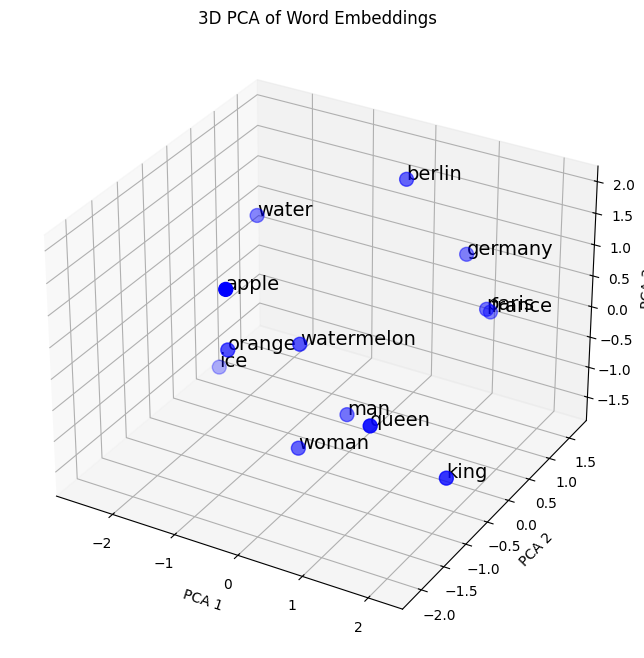


✨ Experiment Complete! ✨


In [6]:
print("[4/4] Evaluating Embeddings...\n")

test_words = [
    "man", "woman", "king", "queen", "apple", "orange", 
    "water", "ice", "paris", "berlin", "france", "germany", "watermelon"
]

# Print top 5 similar words
target_word = "orange"
print(f"Most similar to '{target_word}':")
try:
    for word, score in pipeline.most_similar(target_word, top_k=5):
        print(f"  - {word}: {score:.4f}")
except KeyError:
    print(f"  '{target_word}' is not in the vocabulary. Try a larger dataset size!")

# Generate the 3D Plot
print("\nGenerating 3D PCA visualization...")
plot_word_embeddings_3d(pipeline, test_words)

print("\n✨ Experiment Complete! ✨")